In [37]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

from konlpy.tag import Mecab
from collections import Counter
import pickle

print(torch.__version__)

2.7.1+cu118


In [38]:
# 하이퍼파라미터 설정
VOCAB_SIZE = 10000 
MAX_LEN = 40       


## 폰트설정

현재 설정된 폰트: ['NanumBarunGothic']


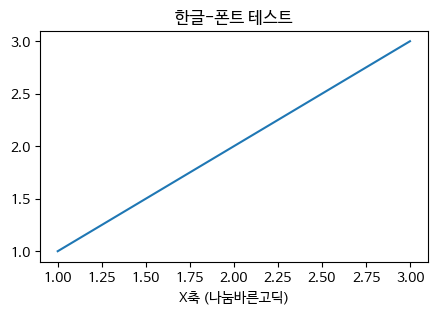

In [39]:
# 폰트 매니저 관련 불필요한 로그 끄기
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 윈도우에 설치된 나눔바른고딕 경로 설정
fontpath = "C:/Users/sr/AppData/Local/Microsoft/Windows/Fonts/NanumBarunGothic.ttf"

# 폰트 속성 적용
font_name = fm.FontProperties(fname=fontpath).get_name()

# 폰트 매니저에 폰트 추가 (윈도우 환경에서 안정성 확보)
fm.fontManager.addfont(fontpath)

# 전역 설정 업데이트
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")

plt.figure(figsize=(5, 3))
plt.title("한글-폰트 테스트")
plt.plot([1, 2, 3], [1, 2, 3])
plt.xlabel("X축 (나눔바른고딕)")
plt.show()

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 데이터 전처리
### 데이터 준비

In [41]:
dataset_dir = os.path.expanduser("datasets")
os.makedirs(dataset_dir, exist_ok=True)

def load_data(path):
    with open(path + '/korean-english-park.train.ko', 'r', encoding='utf-8') as f:
        kor_raw = f.read().splitlines()
    with open(path + '/korean-english-park.train.en', 'r', encoding='utf-8') as f:
        eng_raw = f.read().splitlines()
    return kor_raw, eng_raw

# 데이터 로드
kor_raw, eng_raw = load_data(dataset_dir)
print("데이터셋 디렉토리:", os.listdir(dataset_dir))

# DataFrame 생성
df = pd.DataFrame({
    'korean': kor_raw,
    'english': eng_raw
})

# 상위 5개 데이터 확인
print(f"전체 데이터 개수: {len(df)}")
df.head()

데이터셋 디렉토리: ['korean-english-park.train.en', 'korean-english-park.train.ko']
전체 데이터 개수: 94123


,korean,english
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


### 데이터 정제

In [42]:
print("--- 결측치 확인 ---")
print(df.isnull().sum())

--- 결측치 확인 ---
korean     0
english    0
dtype: int64


In [43]:
# 빈 문자열(공백만 있는 행) 제거
df = df[df['korean'].str.strip() != ""]
df = df[df['english'].str.strip() != ""]

In [44]:
print(f"\n빈 문자열 제거 후 데이터 개수: {len(df)}")


빈 문자열 제거 후 데이터 개수: 94123


In [45]:
# 1. 중복된 행들만 추출 (keep=False를 설정하면 중복된 모든 행을 보여줍니다)
duplicated_data = df[df.duplicated(subset=['korean', 'english'], keep=False)]

# 2. 확인을 위해 한국어 기준으로 정렬해서 상위 10개 출력
# 동일한 문장이 어떻게 반복되고 있는지 한눈에 볼 수 있습니다.
print("--- 중복되었던 데이터 예시 (정렬됨) ---")
display(duplicated_data.sort_values(by='korean').head(10))

# 3. 가장 많이 중복된 문장 TOP 5 확인
print("\n--- 가장 많이 반복된 한국어 문장 TOP 10 ---")
print(df['korean'].value_counts().head(10))

--- 중복되었던 데이터 예시 (정렬됨) ---


,korean,english
50523,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
51567,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
51045,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
50262,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
50001,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
51306,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
50784,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
49740,"""그것은 정말 도전적인 연극이며 만약 내가 성공을 거둘 수 있다면-아직 그럴 수 있...","""It's a really challenging play, and if I can ..."
50488,"""그는 내 아버지의 성질을 돋구려고 했다'고 그녀는 말했다.","""He was trying to get a rise out of my father,..."
51010,"""그는 내 아버지의 성질을 돋구려고 했다'고 그녀는 말했다.","""He was trying to get a rise out of my father,..."



--- 가장 많이 반복된 한국어 문장 TOP 10 ---
korean
[동영상]추신수 스리런 홈런 작렬!      554
더 내려야 하는 이유              554
홍콩 닭장 아파트 생활             554
잭슨 소장품 경매 장갑 최고가 낙...    554
와~ 보아, 미국에서 벌써 6위래요!     554
기후변화의 피해자, 개도국 여성        554
수잔 보일 데뷔 음반 예약주문 1...    554
케냐 야생동물 고아원              554
WBC 베네수엘라戰, 승리를 기원합니다    554
4억 소녀, 또 비키니 입고 노출…      554
Name: count, dtype: int64


In [46]:
# 중복 제거
print(f"중복 제거 전 데이터 개수: {len(df)}")
df.drop_duplicates(subset=['korean', 'english'], inplace=True)
print(f"중복 제거 후 데이터 개수: {len(df)}")

중복 제거 전 데이터 개수: 94123
중복 제거 후 데이터 개수: 78968


In [47]:
# 전처리 함수 정의 (한글 정규식 포함)
def preprocess_sentence(sentence):
    # 양끝 공백 제거 및 소문자화
    sentence = sentence.lower().strip()
    # 구두점 분리 (정규식)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    # 한글, 영어, 숫자, 주요 문장부호 제외 제거
    sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9?.!,]+", " ", sentence)    
    return sentence.strip()

# 전처리 적용
df['cleaned_kor'] = df['korean'].apply(preprocess_sentence)
df['cleaned_eng'] = df['english'].apply(preprocess_sentence)

df.head()

,korean,english,cleaned_kor,cleaned_eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t...",개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee...",그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...,"79 . 95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


### 정제 후 길이 분포 확인

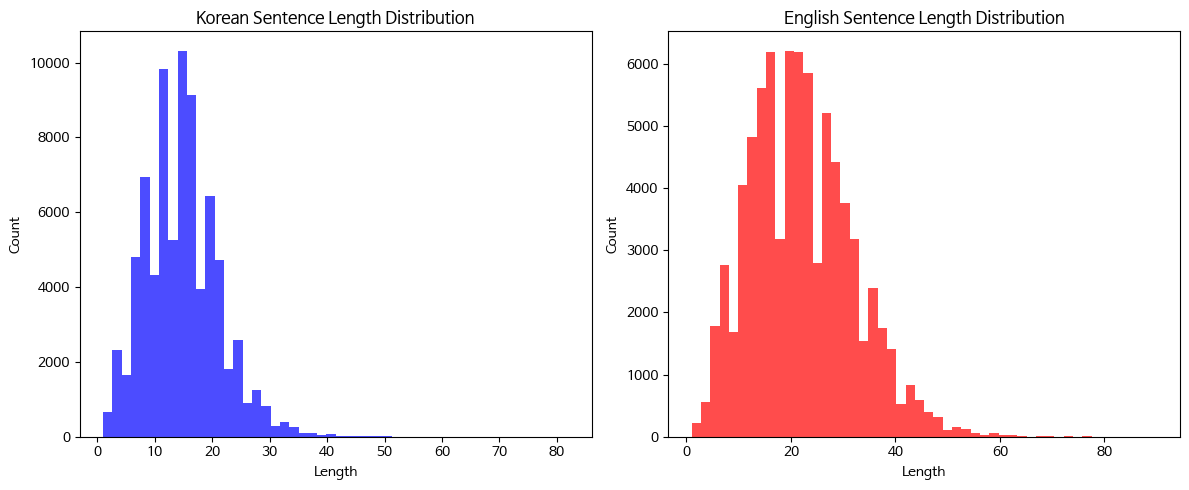

길이 40 이하 선별 전 데이터 개수: 78968
길이 40 이하 선별 후 데이터 개수: 75577


In [48]:
# 간단한 띄어쓰기 기준 토큰화로 길이 계산 (정식 토큰화 전 대략적인 분포 확인)
df['kor_len'] = df['korean'].apply(lambda x: len(str(x).split()))
df['eng_len'] = df['english'].apply(lambda x: len(str(x).split()))

# 길이 분포 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['kor_len'], bins=50, color='blue', alpha=0.7)
plt.title('Korean Sentence Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(df['eng_len'], bins=50, color='red', alpha=0.7)
plt.title('English Sentence Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 길이 40 이하인 데이터만 선별
print(f"길이 40 이하 선별 전 데이터 개수: {len(df)}")
df = df[(df['kor_len'] <= MAX_LEN) & (df['eng_len'] <= MAX_LEN)]
print(f"길이 40 이하 선별 후 데이터 개수: {len(df)}")

### 토큰화 및 단어사전 생성

In [49]:
# 클래스 초기화
mecab = Mecab(dicpath="C:/Users/sr/anaconda3/envs/aiffel_nlp/Lib/site-packages/mecab-ko-dic")

# 형태소 분석 예시
tokens = mecab.morphs("아버지가방에들어가신다")
print(tokens)

['아버지', '가', '방', '에', '들어가', '신다']


In [50]:
def build_and_save_fixed_vocab(corpus, vocab_size, name, vocab_dir):
    """
    단어 사전을 생성하고 지정된 디렉토리에 저장합니다.
    """
    if not os.path.exists(vocab_dir):
        os.makedirs(vocab_dir)

    all_words = []
    for line in tqdm(corpus, desc=f"Building {name.upper()} Vocab"):
        if isinstance(line, str):
            # 한국어(kor)는 Mecab, 영어(eng)는 소문자화 후 split
            tokens = mecab.morphs(line) if name == 'kor' else line.lower().split()
        else:
            tokens = line
        all_words.extend(tokens)
    
    counts = Counter(all_words)
    # 특수 토큰 4개 제외 상위 단어 추출
    top_words = [word for word, count in counts.most_common(vocab_size - 4)]
    
    # 인덱스 고정
    word2idx = {'<pad>': 0, '<unk>': 1, '<start>': 2, '<end>': 3}
    for i, word in enumerate(top_words):
        word2idx[word] = i + 4
        
    idx2word = {idx: word for word, idx in word2idx.items()}
    
    # pickle 저장
    with open(os.path.join(vocab_dir, f'{name}_word2idx.pkl'), 'wb') as f:
        pickle.dump(word2idx, f)
    with open(os.path.join(vocab_dir, f'{name}_idx2word.pkl'), 'wb') as f:
        pickle.dump(idx2word, f)
        
    print(f"[{name.upper()}] Vocab Size: {len(word2idx)} -> Saved in: {vocab_dir}")
    return word2idx, idx2word

### 텐서 변환 및 패딩

In [51]:
def tokenize_and_pad(corpus, word2idx, max_len, is_english=False):
    """
    생성된 사전을 바탕으로 문장을 텐서로 변환하고 패딩을 적용합니다.
    """
    tensor = []
    unk_idx = word2idx['<unk>']
    pad_idx = word2idx['<pad>']
    
    for line in corpus:
        if isinstance(line, str):
            # [중요] build_and_save_fixed_vocab와 동일한 토큰화 로직 적용
            if is_english:
                tokens = line.lower().split()
            else:
                tokens = mecab.morphs(line)
        else:
            tokens = line
        
        # 인덱스 변환
        if is_english:
            # 영어(Decoder): <start> + tokens + <end>
            indexed = [word2idx['<start>']] + \
                      [word2idx.get(w, unk_idx) for w in tokens] + \
                      [word2idx['<end>']]
        else:
            # 한국어(Encoder): tokens
            indexed = [word2idx.get(w, unk_idx) for w in tokens]
        
        # Truncation: max_len에 맞춰 자르기
        indexed = indexed[:max_len]
        
        # Padding: 부족한 만큼 pad_idx(0) 채우기
        if len(indexed) < max_len:
            indexed += [pad_idx] * (max_len - len(indexed))
            
        tensor.append(indexed)
        
    return torch.LongTensor(tensor)

In [110]:
# 실험 설정
VOCAB_SIZE = 10000
CURRENT_EXP_DIR = 'vocab_exp_mecab_10k' # 실험 폴더명 변경으로 관리

# 1. 사전 생성 (Mecab 기반)
kor_word2idx, kor_idx2word = build_and_save_fixed_vocab(df['cleaned_kor'], VOCAB_SIZE, 'kor', CURRENT_EXP_DIR)
eng_word2idx, eng_idx2word = build_and_save_fixed_vocab(df['cleaned_eng'], VOCAB_SIZE, 'eng', CURRENT_EXP_DIR)

# 2. 텐서 변환
kor_tensor = tokenize_and_pad(df['cleaned_kor'], kor_word2idx, MAX_LEN, is_english=False)
eng_tensor = tokenize_and_pad(df['cleaned_eng'], eng_word2idx, MAX_LEN, is_english=True)

print(kor_tensor.shape) # (데이터개수, MAX_LEN)
print(eng_tensor.shape) # (데이터개수, MAX_LEN)

Building KOR Vocab: 100%|██████████| 75577/75577 [00:04<00:00, 17586.11it/s]


[KOR] Vocab Size: 10000 -> Saved in: vocab_exp_mecab_10k


Building ENG Vocab: 100%|██████████| 75577/75577 [00:00<00:00, 665782.26it/s]


[ENG] Vocab Size: 10000 -> Saved in: vocab_exp_mecab_10k
torch.Size([75577, 40])
torch.Size([75577, 40])


In [53]:
# 단어사전 테스트

# 한국어 상위 10개 (특수 토큰 제외하고 실제 단어만)
kor_top_10 = sorted(kor_word2idx.items(), key=lambda x: x[1])[:14] # 특수토큰 4개 포함

print("=== 한국어 사전 상위 10개 (특수토큰 포함) ===")
for word, idx in kor_top_10:
    print(f"Index {idx}: {word}")

print("\n" + "="*30 + "\n")

# 영어 상위 10개
eng_top_10 = sorted(eng_word2idx.items(), key=lambda x: x[1])[:14]

print("=== 영어 사전 상위 10개 (특수토큰 포함) ===")
for word, idx in eng_top_10:
    print(f"Index {idx}: {word}")

=== 한국어 사전 상위 10개 (특수토큰 포함) ===
Index 0: <pad>
Index 1: <unk>
Index 2: <start>
Index 3: <end>
Index 4: .
Index 5: 다
Index 6: 이
Index 7: 는
Index 8: 을
Index 9: 의
Index 10: 에
Index 11: 은
Index 12: 를
Index 13: 하


=== 영어 사전 상위 10개 (특수토큰 포함) ===
Index 0: <pad>
Index 1: <unk>
Index 2: <start>
Index 3: <end>
Index 4: the
Index 5: .
Index 6: ,
Index 7: to
Index 8: of
Index 9: a
Index 10: in
Index 11: and
Index 12: s
Index 13: said


### 영어사전 index 에러 현상 (해결)
```
=== 영어 사전 상위 10개 (특수토큰 포함) ===
Index 0: <pad>
Index 1: <unk>
Index 4: the
Index 5: .
Index 6: <start>
Index 6: <end>
Index 6: ,
Index 7: to
Index 8: of
Index 9: a
Index 10: in
Index 11: and
Index 12: s
Index 13: said

이런 현상이 발생하여 영어 역토큰화시
=== 저장된 폴더 내 사전을 이용한 역토큰화 === 
Sample 1
  KOR: 개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 <unk> 수 있 느냐 ?
  ENG: , much of personal computing is about can you top this ? ,

이렇게 콤마가 붙는 현상이 발생하였다.

토큰을 고정하며 해결하였다.
```

### 단어사전 역토큰화 테스트

- UNK 토큰이 많이 나오면 안되는것에 주의

In [54]:
# 1. 폴더 경로
def load_vocab(vocab_dir, name):
    path = os.path.join(vocab_dir, f'{name}.pkl')
    with open(path, 'rb') as f:
        return pickle.load(f)

# 2. 역토큰화 테스트 함수 (특수 토큰 처리 개선)
def decode_sequence(tensor, idx2word):
    sentence = []
    for idx in tensor:
        idx_val = int(idx)
        if idx_val not in idx2word: # 혹시 모를 에러 방지
            sentence.append('<unk>')
            continue
            
        word = idx2word[idx_val]
        
        if word == '<pad>': continue # 패딩은 그냥 건너뛰기
        sentence.append(word)
        if word == '<end>': break # 문장 끝 만나면 종료
        
    return " ".join(sentence)

In [55]:
# --- 실험별로 사전을 선택해서 로드 가능 ---
CURRENT_EXP_DIR = 'vocab_exp_mecab_10k'

loaded_kor_idx2word = load_vocab(CURRENT_EXP_DIR, 'kor_idx2word')
loaded_eng_idx2word = load_vocab(CURRENT_EXP_DIR, 'eng_idx2word')

# 샘플 확인
print(f"\n=== [{CURRENT_EXP_DIR}] 사전을 이용한 역토큰화 === ")
for i in range(10):
    print(f"Sample {i+1}")
    print(f"  [KOR]: {decode_sequence(kor_tensor[i], loaded_kor_idx2word)}")
    print(f"  [ENG]: {decode_sequence(eng_tensor[i], loaded_eng_idx2word)}")


=== [vocab_exp_mecab_10k] 사전을 이용한 역토큰화 === 
Sample 1
  [KOR]: 개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 <unk> 수 있 느냐 ?
  [ENG]: <start> much of personal computing is about can you top this ? <end>
Sample 2
  [KOR]: 모든 광 마우스 와 마찬가지 로 이 광 마우스 도 책상 위 에 놓 는 마우스 <unk> 를 필요 로 하 지 않 는다 .
  [ENG]: <start> so a mention a few weeks ago about a <unk> wireless <unk> mouse brought in another <unk> , wireless mouse . <end>
Sample 3
  [KOR]: 그러나 이것 은 또한 책상 도 필요 로 하 지 않 는다 .
  [ENG]: <start> like all <unk> mice , but it also doesn t need a desk . <end>
Sample 4
  [KOR]: 79 . 95 달러 하 는 이 최첨단 무선 광 마우스 는 <unk> 에서 <unk> , 팔 , 그 외 에 어떤 부분 이 든 그 움직임 에 따라 <unk> 의 움직임 을 조절 하 는 회전 운동 센서 를
  [ENG]: <start> uses <unk> sensors to control the <unk> movement as you move your wrist , arm , whatever through the air . <end>
Sample 5
  [KOR]: 정보 관리 들 은 동남 아시아 에서 의 선박 들 에 대한 많 은 테러 계획 들 이 실패 로 돌아갔 음 을 밝혔으며 , 세계 해상 교역 량 의 거의 3 분 의 1 을 운송 하 는 좁
  [ENG]: <start> intelligence officials have revealed a spate of foiled plots on ships in s

In [56]:
# 테스트할 한국어 샘플
kor_sample = "새로운 인공 지능 프로그램은 성능이 아주 뛰어납니다."

# 1. 형태소 분석 (Tokenization)
tokens = mecab.morphs(kor_sample)
print(f"Tokens: {tokens}")

# 2. 숫자로 변환 (Encoding)
enc_token = [kor_word2idx['<start>']] + \
            [kor_word2idx.get(w, kor_word2idx['<unk>']) for w in tokens] + \
            [kor_word2idx['<end>']]

print(f"Encoded: {enc_token}")

# 3. 다시 문장으로 복원 (Decoding - 역토큰화 확인)
decoded = [kor_idx2word[idx] for idx in enc_token]
print(f"Decoded: {' '.join(decoded)}")

Tokens: ['새로운', '인공', '지능', '프로그램', '은', '성능', '이', '아주', '뛰어납니다', '.']
Encoded: [2, 251, 4058, 1, 325, 11, 5441, 6, 1096, 1, 4, 3]
Decoded: <start> 새로운 인공 <unk> 프로그램 은 성능 이 아주 <unk> . <end>


In [57]:
# 테스트할 영어 샘플
eng_sample = "the book i bought yesterday was much more interesting than i thought."

# 1. 토큰화 (가이드라인: split() 사용)
# 이미 전처리를 통해 구두점 양옆에 공백이 있다고 가정합니다.
tokens_eng = eng_sample.split()

# 2. <start>, <end> 추가 및 인코딩
# eng_word2idx 사전을 사용합니다.
enc_token_eng = [eng_word2idx['<start>']] + \
                [eng_word2idx.get(w, eng_word2idx['<unk>']) for w in tokens_eng] + \
                [eng_word2idx['<end>']]

print(f"English Tokens: {tokens_eng}")
print(f"English Encoded: {enc_token_eng}")

# 3. 역토큰화 확인 (불러온 사전을 사용)
decoded_eng = [eng_idx2word[idx] for idx in enc_token_eng]
print(f"English Decoded: {' '.join(decoded_eng)}")

English Tokens: ['the', 'book', 'i', 'bought', 'yesterday', 'was', 'much', 'more', 'interesting', 'than', 'i', 'thought.']
English Encoded: [2, 4, 1117, 55, 2313, 288, 18, 282, 47, 5371, 63, 55, 1, 3]
English Decoded: <start> the book i bought yesterday was much more interesting than i <unk> <end>


## 모델 설계

In [58]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [59]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [60]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [61]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 2, eos_id=3):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [62]:
input_dim = len(kor_word2idx) # 한국어 사전 크기
output_dim = len(eng_word2idx) # 영어 사전 크기

# 하이퍼파라미터 설정
emb_dim = 256
hid_dim = 512

# 장치 확인
print(device)

cuda


In [63]:
# 모델 객체 생성 및 GPU 이동
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(f"Model initialized on: {device}")
print(f"Input Dim: {input_dim}, Output Dim: {output_dim}")

Model initialized on: cuda
Input Dim: 10000, Output Dim: 10000


In [64]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=10000, bias=True)
  )
)


## 학습 준비
### dataset

In [65]:
class TranslationDataset(Dataset):
    def __init__(self, data, kor_vocab, eng_vocab, max_len):
        self.data = data
        self.kor_vocab = kor_vocab
        self.eng_vocab = eng_vocab
        self.max_len = max_len
        
        # 특수 토큰 인덱스 고정
        self.pad_id = self.kor_vocab['<pad>']   # 0
        self.unk_id = self.kor_vocab['<unk>']   # 1
        self.bos_id = self.eng_vocab['<start>'] # 2
        self.eos_id = self.eng_vocab['<end>']   # 3
        
        # 한국어 토크나이저 준비
        self.mecab = mecab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. 데이터 추출 (컬럼명 확인: cleaned_kor, cleaned_eng)
        src_text = self.data.iloc[idx]['cleaned_kor']
        trg_text = self.data.iloc[idx]['cleaned_eng']

        # 2. 한국어 토큰화 및 인덱싱 (Mecab 사용)
        src_tokens = self.mecab.morphs(src_text)
        src_ids = [self.kor_vocab.get(w, self.unk_id) for w in src_tokens]
        src_ids = src_ids[:self.max_len] # 길이 제한

        # 3. 영어 토큰화 및 인덱싱 (소문자화 + split)
        trg_tokens = trg_text.lower().split()
        trg_ids = [self.eng_vocab.get(w, self.unk_id) for w in trg_tokens]

        # 4. Decoder 입력(trg_input)과 정답(trg_label) 생성
        # trg_input: <start> + tokens + <end>
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        # trg_label: tokens + <end> (Loss 계산용, <start> 제외)
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 5. Padding 처리
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return (torch.tensor(src_ids, dtype=torch.long), 
                torch.tensor(trg_input, dtype=torch.long), 
                torch.tensor(trg_label, dtype=torch.long))

### 데이터 분할 , dataset, dataloader

In [66]:
train_ratio = 0.8
BATCH_SIZE = 128

# 데이터 분할
train_df = df.sample(frac=train_ratio, random_state=42)
valid_df = df.drop(train_df.index)

train_df.reset_index(drop=True, inplace=True)
valid_df.reset_index(drop=True, inplace=True)

# Dataset 생성
train_dataset = TranslationDataset(
    train_df, 
    kor_word2idx, 
    eng_word2idx, 
    max_len=MAX_LEN
)
valid_dataset = TranslationDataset(
    valid_df, 
    kor_word2idx, 
    eng_word2idx, 
    max_len=MAX_LEN
)

# DataLoader 설정
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    valid_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

## 훈련
### Optimizer & Loss

In [67]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0) # 사전 생성 시 <pad>: 0 으로 설정했으므로

### train_step

In [68]:
def calculate_accuracy(preds, y, pad_idx):
    # preds: (N, output_dim), y: (N)
    top_pred = preds.argmax(1, keepdim=True) # 가장 높은 확률의 단어 인덱스
    
    # 패딩이 아닌 토큰들만 골라내는 마스크 (True/False)
    non_pad_mask = y.ne(pad_idx) 
    
    # 예측값과 실제값이 일치하는지 확인
    correct = top_pred.eq(y.view_as(top_pred))
    
    # 패딩이 아닌 부분 중에서 맞춘 개수만 합산
    correct_count = correct.masked_select(non_pad_mask).sum().item()
    
    # 패딩이 아닌 전체 토큰 개수
    total_count = non_pad_mask.sum().item()
    
    # 0으로 나누기 방지 및 비율 리턴 (0.0 ~ 1.0 사이 값)
    return correct_count / total_count if total_count > 0 else 0.0

In [69]:
def train_epoch(model, iterator, optimizer, criterion, clip, pad_idx):
    model.train() # 학습 모드: Dropout 등이 활성화됨
    epoch_loss = 0
    epoch_acc = 0
    
    for src, trg_input, trg_label in tqdm(iterator, desc="Training"):
        # 1. 데이터 전처리 및 GPU 이동
        # .T: (Batch, Seq) -> (Seq, Batch)로 축 변경
        # .contiguous(): 전치 연산 후 꼬인 메모리 주소를 연속적으로 재배치 (RuntimeError 방지 핵심)
        src = src.to(device).T.contiguous()           
        trg_input = trg_input.to(device).T.contiguous() 
        trg_label = trg_label.to(device).T.contiguous() 
        
        optimizer.zero_grad() # 이전 루프의 기울기 초기화
        
        # 2. 모델 예측
        # output: (trg_len, batch_size, output_dim)
        output, _ = model(src, trg_input)
        
        # 3. Loss 계산을 위한 차원 변형
        # CrossEntropyLoss는 (N, C) 형태를 요구하므로 (시퀀스*배치)를 하나의 차원으로 펼침
        output_dim = output.shape[-1]
        
        # .contiguous()를 다시 한 번 호출하여 view 연산이 안전하게 수행되도록 함
        output = output.contiguous().view(-1, output_dim) 
        trg_label = trg_label.view(-1) # 정답 라벨도 (시퀀스*배치) 크기의 1차원으로 펼침
        
        # 4. 오차 계산 및 역전파
        loss = criterion(output, trg_label)
        acc = calculate_accuracy(output, trg_label, pad_idx) # 패딩을 제외한 정확도 계산
        
        loss.backward() # 기울기(Gradient) 계산
        
        # 5. 기울기 폭주 방지 (Gradient Clipping)
        # 기울기 값이 임계값(clip)을 넘지 않도록 강제로 깎아 모델 안정성 확보
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step() # 가중치 업데이트
        
        epoch_loss += loss.item()
        epoch_acc += acc
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [103]:
def evaluate(model, iterator, criterion, pad_idx):
    model.eval() # 평가 모드: 가중치 업데이트를 하지 않으며 Dropout 비활성화
    epoch_loss = 0
    epoch_acc = 0
    
    # 평가 시에는 기울기를 계산할 필요가 없으므로 메모리와 속도를 위해 설정
    with torch.no_grad():
        for src, trg_input, trg_label in tqdm(iterator, desc="Evaluating"):
            # 데이터 전송 및 메모리 최적화
            src = src.to(device).T.contiguous()
            trg_input = trg_input.to(device).T.contiguous()
            trg_label = trg_label.to(device).T.contiguous()
            
            # 순전파(Forward)만 수행
            output, _ = model(src, trg_input)
            
            # 차원 변형 (학습 함수와 동일한 로직)
            output_dim = output.shape[-1]
            output = output.contiguous().view(-1, output_dim)
            trg_label = trg_label.view(-1)
            
            # 성능 지표 누적
            loss = criterion(output, trg_label)
            acc = calculate_accuracy(output, trg_label, pad_idx)
            
            epoch_loss += loss.item()
            epoch_acc += acc
            
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [73]:
def run_experiment(model, train_loader, val_loader, optimizer, criterion, 
                   n_epochs, clip, pad_idx, vocab_type, vocab_size, 
                   emb_dim, hid_dim, lr, save_dir='experiments'):
    
    # 1. 실험 이름 생성 및 전용 하위 폴더 경로 설정
    exp_name = f"{vocab_type}_{vocab_size}_emb{emb_dim}_hid{hid_dim}_lr{lr}"
    exp_path = os.path.join(save_dir, exp_name) # experiments/mecab_10k_... 형태
    
    # 해당 실험 전용 폴더가 없으면 생성
    if not os.path.exists(exp_path):
        os.makedirs(exp_path)
        
    print(f"🚀 Starting Experiment: {exp_name}")
    print(f"📂 Results will be saved in: {exp_path}")
    
    history = {
        'epoch': [],
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_valid_loss = float('inf')

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, clip, pad_idx)
        val_loss, val_acc = evaluate(model, val_loader, criterion, pad_idx)
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # 가중치 저장 (해당 실험 폴더 안에 저장)
        if val_loss < best_valid_loss:
            best_valid_loss = val_loss

            torch.save(model.state_dict(), f'{exp_path}/best_model.pt')
            print(f'>>> Best Model Saved! (Loss: {val_loss:.4f})')
            
        print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.4f}')

    # CSV 저장 (해당 실험 폴더 안에 저장)
    csv_path = f'{exp_path}/history.csv'
    pd.DataFrame(history).to_csv(csv_path, index=False)
    print(f"✅ Experiment results saved to: {csv_path}")

    return history

In [74]:
# --- 하이퍼파라미터 설정 ---
V_TYPE = 'mecab'
V_SIZE = '10k'
E_DIM = 256
H_DIM = 512
LEARNING_RATE = 1e-3
EPOCHS = 10
CLIP_VAL = 1
PAD_ID = 0

# --- 함수 실행 ---
# 수정된 run_experiment는 내부에서 exp_name을 만들고 폴더를 생성합니다.
exp_history = run_experiment(
    model = model,
    train_loader = train_loader,
    val_loader = validation_loader,
    optimizer = optimizer,
    criterion = criterion,
    n_epochs = EPOCHS,
    clip = CLIP_VAL,
    pad_idx = PAD_ID,
    vocab_type = V_TYPE,     # 폴더명 생성에 사용
    vocab_size = V_SIZE,     # 폴더명 생성에 사용
    emb_dim = E_DIM,         # 폴더명 생성에 사용
    hid_dim = H_DIM,         # 폴더명 생성에 사용
    lr = LEARNING_RATE,      # 폴더명 생성에 사용
    save_dir = 'experiments' # 최상위 저장 폴더
)

🚀 Starting Experiment: mecab_10k_emb256_hid512_lr0.001
📂 Results will be saved in: experiments\mecab_10k_emb256_hid512_lr0.001


Evaluating: 100%|██████████| 119/119 [00:12<00:00,  9.60it/s]


>>> Best Model Saved! (Loss: 3.9859)
Epoch: 01 | Train Loss: 3.520 | Train Acc: 1051.0085 | Val Loss: 3.986 | Val Acc: 960.9748


Evaluating: 100%|██████████| 119/119 [00:12<00:00,  9.69it/s]


>>> Best Model Saved! (Loss: 3.9625)
Epoch: 02 | Train Loss: 3.058 | Train Acc: 1200.0275 | Val Loss: 3.963 | Val Acc: 975.3866


...

Epoch: 08 | Train Loss: 1.518 | Train Acc: 2023.1564 | Val Loss: 4.605 | Val Acc: 905.3193


Evaluating: 100%|██████████| 119/119 [00:12<00:00,  9.69it/s]


Epoch: 09 | Train Loss: 1.383 | Train Acc: 2112.9556 | Val Loss: 4.748 | Val Acc: 895.7647


Evaluating: 100%|██████████| 119/119 [00:12<00:00,  9.63it/s]

Epoch: 10 | Train Loss: 1.266 | Train Acc: 2190.0254 | Val Loss: 4.894 | Val Acc: 884.2689
✅ Experiment results saved to: experiments\mecab_10k_emb256_hid512_lr0.001/history.csv


In [76]:
import seaborn as sns

def plot_history(exp_name, save_dir='experiments'):
    # 데이터 로드
    csv_path = os.path.join(save_dir, exp_name, 'history.csv')
    if not os.path.exists(csv_path):
        print(f"❌ 파일을 찾을 수 없습니다: {csv_path}")
        return
    
    df = pd.read_csv(csv_path)
    sns.set_style("whitegrid")
    
    fig, ax1 = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f"Experiment: {exp_name}", fontsize=16)

    # 1. Loss Curve
    ax1[0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
    ax1[0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
    ax1[0].set_title('Loss Trend')
    ax1[0].set_xlabel('Epoch')
    ax1[0].set_ylabel('Loss')
    ax1[0].legend()

    # 2. Accuracy Curve
    # 현재 Acc 값이 크므로 로그 스케일이나 정규화를 고려할 수 있지만, 일단 그대로 그립니다.
    ax1[1].plot(df['epoch'], df['train_acc'], label='Train Acc', color='green', marker='o')
    ax1[1].plot(df['epoch'], df['val_acc'], label='Val Acc', color='orange', marker='s')
    ax1[1].set_title('Accuracy Trend (Raw Values)')
    ax1[1].set_xlabel('Epoch')
    ax1[1].set_ylabel('Accuracy')
    ax1[1].legend()

    plt.tight_layout()
    
    # 그래프 저장
    plot_path = os.path.join(save_dir, exp_name, 'result_plot.png')
    plt.savefig(plot_path)
    plt.show()
    print(f"✅ 그래프가 저장되었습니다: {plot_path}")



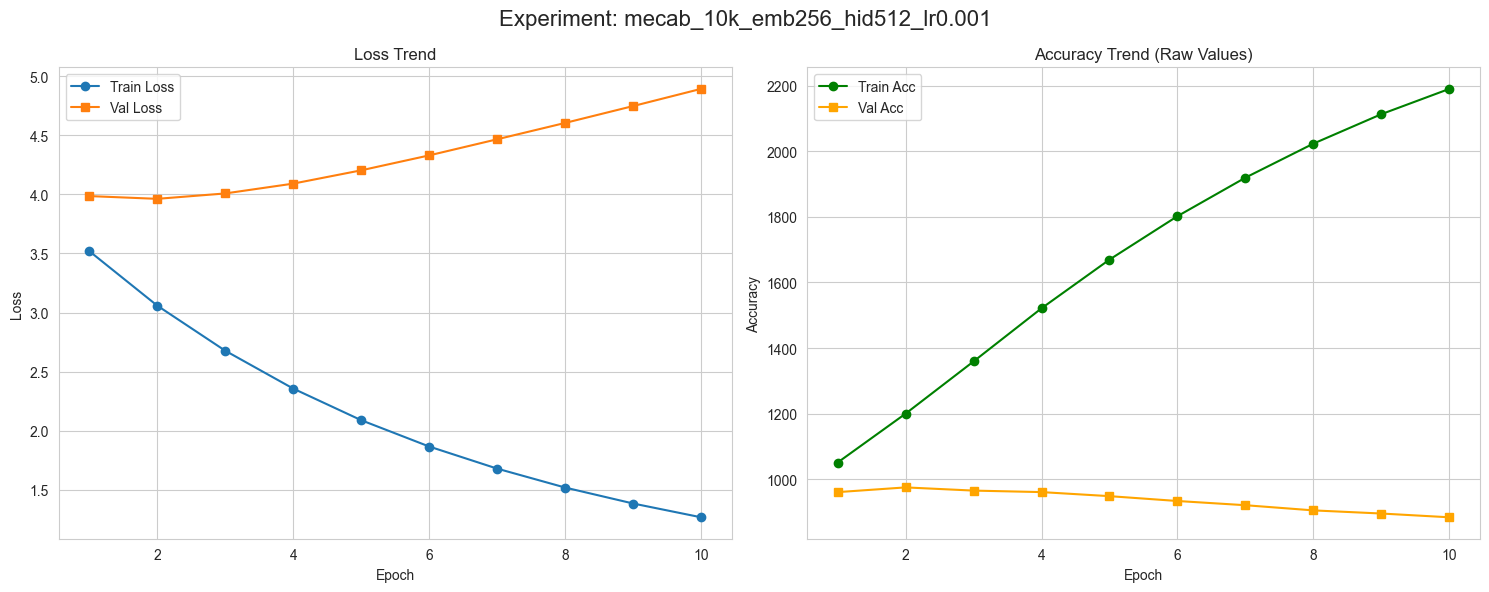

✅ 그래프가 저장되었습니다: experiments\mecab_10k_emb256_hid512_lr0.001\result_plot.png


In [77]:
plot_history("mecab_10k_emb256_hid512_lr0.001")

## 번역 수행

In [111]:
def evaluate_sentence(sentence, model, kor_word2idx, eng_idx2word, max_len=30):
    model.eval()

    # 1. 소스 문장 토큰화 및 인덱싱 (Mecab 등 사용)
    sentence = preprocess_sentence(sentence) 

    # 딕셔너리를 사용하여 인덱스로 변환 (없는 단어는 <unk> 처리)
    src_ids = [kor_word2idx.get(w, kor_word2idx.get('<unk>', 1)) for w in mecab.morphs(sentence)]
    actual_src_len = len(src_ids) if len(src_ids) < max_len else max_len
    
    # 패딩 및 텐서화
    src_ids = src_ids[:max_len] + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    # 2. 타겟 문장 디코딩 (idx2word 딕셔너리 사용)
    pred_ids = outputs.argmax(2).squeeze(1).tolist()
    result = []
    for token_id in pred_ids:
        word = eng_idx2word.get(token_id, '<unk>') # 딕셔너리에서 단어 찾기
        if word == "<end>" or word == "<eos>": # 종료 토큰 확인
            break
        result.append(word)

    # 3. 어텐션 맵 및 소스 토큰 리스트 준비
    att_map = attentions.squeeze(1).cpu().numpy()
    att_map = att_map[:len(result), :actual_src_len]
    
    # x축 라벨용 (인덱스를 다시 단어로)
    src_tokens = [kor_idx2word.get(idx, '<unk>') for idx in src_ids[:actual_src_len]]

    return result, src_tokens, att_map

In [112]:
def plot_attention(attention, sentence, predicted_sentence):
    # 폰트 경로 다시 지정 (확인 필수)
    fontpath = "C:/Users/sr/AppData/Local/Microsoft/Windows/Fonts/NanumBarunGothic.ttf"
    font_prop = fm.FontProperties(fname=fontpath, size=12)
    font_name = font_prop.get_name()

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)

    ax.matshow(attention, cmap='viridis')

    # X축 (한국어) 폰트 강제 지정
    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontproperties=font_prop, rotation=90)
    
    # Y축 (영어) 폰트 강제 지정
    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontproperties=font_prop)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

In [113]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    # 1. 번역 수행 및 데이터 획득
    result, src_tokens, attention = evaluate_sentence(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    # 2. 결과 출력
    print(f'Input: {" ".join(src_tokens)}')
    print(f'Predicted translation: {" ".join(result)}')

    # 3. 시각화 호출
    plot_attention(attention, src_tokens, result)

In [121]:
# 1. 10k에 맞는 차원 설정 
input_dim = 10000
output_dim = 10000

# 2. 모델 객체 다시 생성 및 GPU 이동
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(f"Model re-initialized for 10k on: {device}")
print(f"Input Dim: {input_dim}, Output Dim: {output_dim}")

# 3. 10k 가중치 파일 로드
model_path = 'experiments/mecab_10k_emb256_hid512_lr0.001/best_model.pt'
model.load_state_dict(torch.load(model_path))
model.eval()

print("✅ 10k 가중치 로드 성공!")

Model re-initialized for 10k on: cuda
Input Dim: 10000, Output Dim: 10000
✅ 10k 가중치 로드 성공!


(폰트 설정: NanumBarunGothic)

[K1] 테스트
Input: 오바마 는 대통령 이 다 .
Predicted: obama is the president .


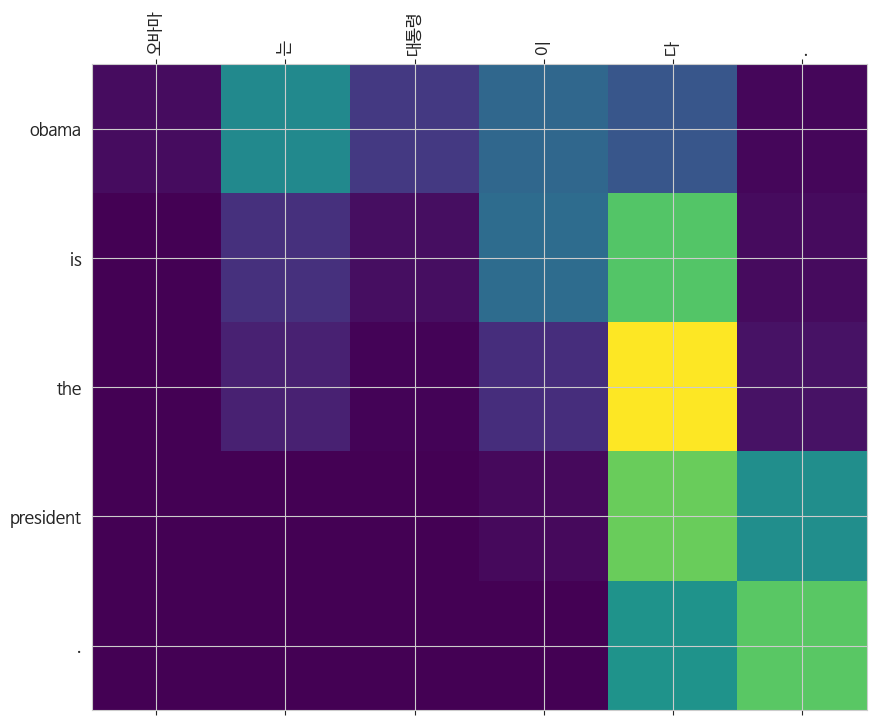


[K2] 테스트
Input: 시민 들 은 도시 속 에 <unk> .
Predicted: citizens , the city s <unk> <unk> .


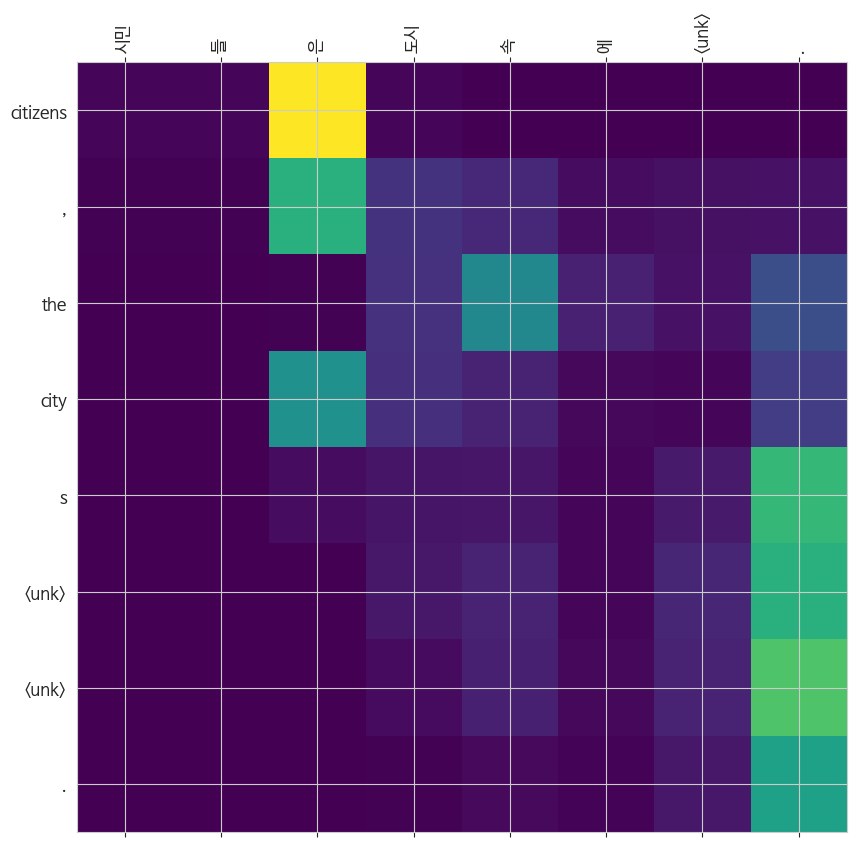


[K3] 테스트
Input: 커피 는 필요 없 다 .
Predicted: the <unk> of the coffee is no longer .


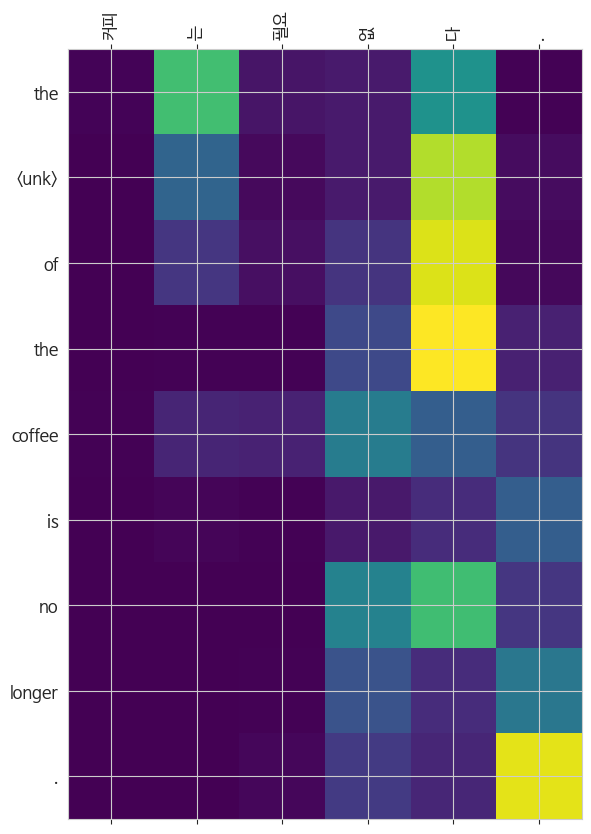


[K4] 테스트
Input: 일곱 명 의 사망자 가 발생 했 다 .
Predicted: the dead were killed .


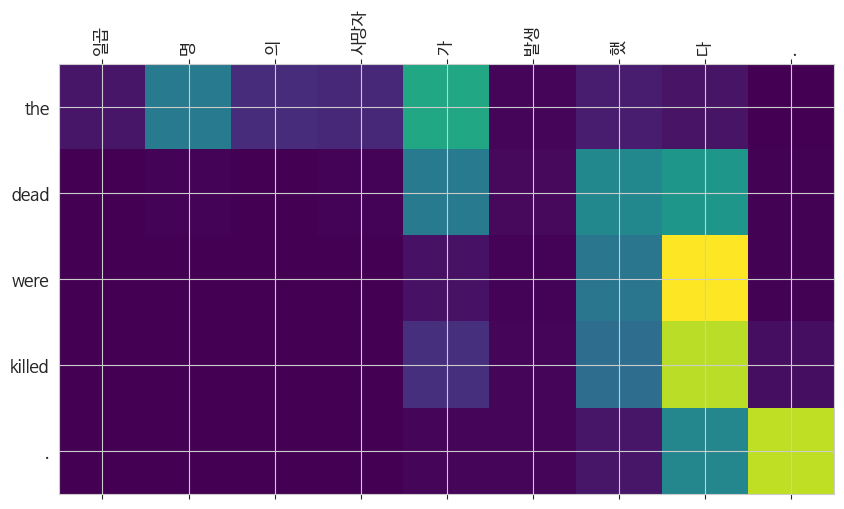

In [122]:
# 테스트 문장 리스트
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

print(f"(폰트 설정: {font_name})")

for i, sent in enumerate(test_sentences):
    print(f"\n[K{i+1}] 테스트")
    # evaluate 함수를 통해 결과 획득 (딕셔너리 버전 사용)
    result, src_tokens, att_map = evaluate_sentence(
        sentence=sent, 
        model=model, 
        kor_word2idx=kor_word2idx, 
        eng_idx2word=eng_idx2word, 
        max_len=MAX_LEN
    )
    
    print(f"Input: {' '.join(src_tokens)}")
    print(f"Predicted: {' '.join(result)}")
    
    # 시각화 (보강된 함수 호출)
    plot_attention(att_map, src_tokens, result)

## Ablation Study
### vocab size 20k 증량

In [123]:
# calculate_accuracy 함수 이상해서 오류 수정

def calculate_accuracy(preds, y, pad_idx):
    top_pred = preds.argmax(1, keepdim=True)
    non_pad_mask = y.ne(pad_idx)
    correct = top_pred.eq(y.view_as(top_pred))
    
    # 맞은 개수 / 전체 토큰 개수 (비율 반환)
    correct_count = correct.masked_select(non_pad_mask).sum().item()
    total_count = non_pad_mask.sum().item()
    
    return correct_count / total_count if total_count > 0 else 0.0

In [124]:
# 실험 설정
VOCAB_SIZE = 20000
CURRENT_EXP_DIR = 'vocab_exp_mecab_20k' # 실험 폴더명 변경으로 관리

# 1. 사전 생성 (Mecab 기반)
kor_word2idx, kor_idx2word = build_and_save_fixed_vocab(df['cleaned_kor'], VOCAB_SIZE, 'kor', CURRENT_EXP_DIR)
eng_word2idx, eng_idx2word = build_and_save_fixed_vocab(df['cleaned_eng'], VOCAB_SIZE, 'eng', CURRENT_EXP_DIR)

# 2. 텐서 변환
kor_tensor = tokenize_and_pad(df['cleaned_kor'], kor_word2idx, MAX_LEN, is_english=False)
eng_tensor = tokenize_and_pad(df['cleaned_eng'], eng_word2idx, MAX_LEN, is_english=True)

print(kor_tensor.shape) # (데이터개수, MAX_LEN)
print(eng_tensor.shape) # (데이터개수, MAX_LEN)

Building KOR Vocab: 100%|██████████| 75577/75577 [00:04<00:00, 18015.17it/s]


[KOR] Vocab Size: 20000 -> Saved in: vocab_exp_mecab_20k


Building ENG Vocab: 100%|██████████| 75577/75577 [00:00<00:00, 607778.42it/s]


[ENG] Vocab Size: 20000 -> Saved in: vocab_exp_mecab_20k
torch.Size([75577, 40])
torch.Size([75577, 40])


In [125]:
# --- 실험별로 사전을 선택해서 로드 가능 ---
loaded_kor_idx2word = load_vocab(CURRENT_EXP_DIR, 'kor_idx2word')
loaded_eng_idx2word = load_vocab(CURRENT_EXP_DIR, 'eng_idx2word')

# 샘플 확인
print(f"\n=== [{CURRENT_EXP_DIR}] 사전을 이용한 역토큰화 === ")
for i in range(10):
    print(f"Sample {i+1}")
    print(f"  [KOR]: {decode_sequence(kor_tensor[i], loaded_kor_idx2word)}")
    print(f"  [ENG]: {decode_sequence(eng_tensor[i], loaded_eng_idx2word)}")


=== [vocab_exp_mecab_20k] 사전을 이용한 역토큰화 === 
Sample 1
  [KOR]: 개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 <unk> 수 있 느냐 ?
  [ENG]: <start> much of personal computing is about can you top this ? <end>
Sample 2
  [KOR]: 모든 광 마우스 와 마찬가지 로 이 광 마우스 도 책상 위 에 놓 는 마우스 패드 를 필요 로 하 지 않 는다 .
  [ENG]: <start> so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse . <end>
Sample 3
  [KOR]: 그러나 이것 은 또한 책상 도 필요 로 하 지 않 는다 .
  [ENG]: <start> like all optical mice , but it also doesn t need a desk . <end>
Sample 4
  [KOR]: 79 . 95 달러 하 는 이 최첨단 무선 광 마우스 는 <unk> 에서 <unk> , 팔 , 그 외 에 어떤 부분 이 든 그 움직임 에 따라 커서 의 움직임 을 조절 하 는 회전 운동 센서 를
  [ENG]: <start> uses <unk> sensors to control the <unk> movement as you move your wrist , arm , whatever through the air . <end>
Sample 5
  [KOR]: 정보 관리 들 은 동남 아시아 에서 의 선박 들 에 대한 많 은 테러 계획 들 이 실패 로 돌아갔 음 을 밝혔으며 , 세계 해상 교역 량 의 거의 3 분 의 1 을 운송 하 는 좁
  [ENG]: <start> intelligence officials have revealed a spate of foiled plots o

In [126]:
input_dim = len(kor_word2idx) # 한국어 사전 크기
output_dim = len(eng_word2idx) # 영어 사전 크기

print(input_dim)
print(output_dim)

# 하이퍼파라미터 설정
emb_dim = 256
hid_dim = 512

# 장치 확인
print(device)

20000
20000
cuda


In [136]:
# 모델 객체 생성 및 GPU 이동
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(f"Model initialized on: {device}")
print(f"Input Dim: {input_dim}, Output Dim: {output_dim}")

Model initialized on: cuda
Input Dim: 20000, Output Dim: 20000


In [137]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=20000, bias=True)
  )
)


In [138]:
train_ratio = 0.8
BATCH_SIZE = 128

# 데이터 분할
train_df = df.sample(frac=train_ratio, random_state=42)
valid_df = df.drop(train_df.index)

train_df.reset_index(drop=True, inplace=True)
valid_df.reset_index(drop=True, inplace=True)

# Dataset 생성
train_dataset = TranslationDataset(
    train_df, 
    kor_word2idx, 
    eng_word2idx, 
    max_len=MAX_LEN
)
valid_dataset = TranslationDataset(
    valid_df, 
    kor_word2idx, 
    eng_word2idx, 
    max_len=MAX_LEN
)

# DataLoader 설정
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    valid_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

In [131]:
# --- 하이퍼파라미터 설정 ---
V_TYPE = 'mecab'
V_SIZE = '20k'
E_DIM = 256
H_DIM = 512
LEARNING_RATE = 1e-3
EPOCHS = 10
CLIP_VAL = 1
PAD_ID = 0

# --- 함수 실행 ---
# 수정된 run_experiment는 내부에서 exp_name을 만들고 폴더를 생성합니다.
exp_history = run_experiment(
    model = model,
    train_loader = train_loader,
    val_loader = validation_loader,
    optimizer = optimizer,
    criterion = criterion,
    n_epochs = EPOCHS,
    clip = CLIP_VAL,
    pad_idx = PAD_ID,
    vocab_type = V_TYPE,     # 폴더명 생성에 사용
    vocab_size = V_SIZE,     # 폴더명 생성에 사용
    emb_dim = E_DIM,         # 폴더명 생성에 사용
    hid_dim = H_DIM,         # 폴더명 생성에 사용
    lr = LEARNING_RATE,      # 폴더명 생성에 사용
    save_dir = 'experiments' # 최상위 저장 폴더
)

🚀 Starting Experiment: mecab_20k_emb256_hid512_lr0.001
📂 Results will be saved in: experiments\mecab_20k_emb256_hid512_lr0.001


Evaluating: 100%|██████████| 119/119 [00:15<00:00,  7.75it/s]


>>> Best Model Saved! (Loss: 9.9107)
Epoch: 01 | Train Loss: 9.911 | Train Acc: 0.0846 | Val Loss: 9.911 | Val Acc: 0.0756


Evaluating: 100%|██████████| 119/119 [00:15<00:00,  7.80it/s]


Epoch: 02 | Train Loss: 9.911 | Train Acc: 0.0846 | Val Loss: 9.911 | Val Acc: 0.0756


Evaluating: 100%|██████████| 119/119 [00:15<00:00,  7.86it/s]


Epoch: 03 | Train Loss: 9.911 | Train Acc: 0.0846 | Val Loss: 9.911 | Val Acc: 0.0756


Training:  21%|██        | 97/473 [00:32<02:05,  3.01it/s]


KeyboardInterrupt: 

In [135]:
# --- 하이퍼파라미터 설정 ---
V_TYPE = 'mecab'
V_SIZE = '20k'
E_DIM = 256
H_DIM = 512
LEARNING_RATE = 2e-3
EPOCHS = 10
CLIP_VAL = 1
PAD_ID = 0

# --- 함수 실행 ---
# 수정된 run_experiment는 내부에서 exp_name을 만들고 폴더를 생성합니다.
exp_history = run_experiment(
    model = model,
    train_loader = train_loader,
    val_loader = validation_loader,
    optimizer = optimizer,
    criterion = criterion,
    n_epochs = EPOCHS,
    clip = CLIP_VAL,
    pad_idx = PAD_ID,
    vocab_type = V_TYPE,     # 폴더명 생성에 사용
    vocab_size = V_SIZE,     # 폴더명 생성에 사용
    emb_dim = E_DIM,         # 폴더명 생성에 사용
    hid_dim = H_DIM,         # 폴더명 생성에 사용
    lr = LEARNING_RATE,      # 폴더명 생성에 사용
    save_dir = 'experiments' # 최상위 저장 폴더
)

🚀 Starting Experiment: mecab_20k_emb256_hid512_lr0.002
📂 Results will be saved in: experiments\mecab_20k_emb256_hid512_lr0.002


Evaluating: 100%|██████████| 119/119 [00:14<00:00,  8.00it/s]


>>> Best Model Saved! (Loss: 9.9209)
Epoch: 01 | Train Loss: 9.921 | Train Acc: 0.0930 | Val Loss: 9.921 | Val Acc: 0.0924


Evaluating: 100%|██████████| 119/119 [00:14<00:00,  8.03it/s]


Epoch: 02 | Train Loss: 9.921 | Train Acc: 0.0930 | Val Loss: 9.921 | Val Acc: 0.0924


Evaluating: 100%|██████████| 119/119 [00:14<00:00,  7.99it/s]


Epoch: 03 | Train Loss: 9.921 | Train Acc: 0.0930 | Val Loss: 9.921 | Val Acc: 0.0924


Training:  21%|██        | 100/473 [00:34<02:09,  2.89it/s]


KeyboardInterrupt: 

In [139]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0) # 사전 생성 시 <pad>: 0 으로 설정했으므로

In [140]:
# --- 하이퍼파라미터 설정 ---
V_TYPE = 'mecab'
V_SIZE = '20k'
E_DIM = 256
H_DIM = 512
LEARNING_RATE = 1e-3
EPOCHS = 10
CLIP_VAL = 1
PAD_ID = 0

# --- 함수 실행 ---
# 수정된 run_experiment는 내부에서 exp_name을 만들고 폴더를 생성합니다.
exp_history = run_experiment(
    model = model,
    train_loader = train_loader,
    val_loader = validation_loader,
    optimizer = optimizer,
    criterion = criterion,
    n_epochs = EPOCHS,
    clip = CLIP_VAL,
    pad_idx = PAD_ID,
    vocab_type = V_TYPE,     # 폴더명 생성에 사용
    vocab_size = V_SIZE,     # 폴더명 생성에 사용
    emb_dim = E_DIM,         # 폴더명 생성에 사용
    hid_dim = H_DIM,         # 폴더명 생성에 사용
    lr = LEARNING_RATE,      # 폴더명 생성에 사용
    save_dir = 'experiments' # 최상위 저장 폴더
)

🚀 Starting Experiment: mecab_20k_emb256_hid512_lr0.001
📂 Results will be saved in: experiments\mecab_20k_emb256_hid512_lr0.001


Evaluating: 100%|██████████| 119/119 [00:14<00:00,  7.96it/s]


>>> Best Model Saved! (Loss: 4.8959)
Epoch: 01 | Train Loss: 5.559 | Train Acc: 638.9239 | Val Loss: 4.896 | Val Acc: 770.8487


Evaluating: 100%|██████████| 119/119 [00:14<00:00,  7.97it/s]


>>> Best Model Saved! (Loss: 4.4435)
Epoch: 02 | Train Loss: 4.375 | Train Acc: 866.2664 | Val Loss: 4.443 | Val Acc: 881.6218


...

Epoch: 08 | Train Loss: 1.735 | Train Acc: 1911.7357 | Val Loss: 4.726 | Val Acc: 904.1008


Evaluating: 100%|██████████| 119/119 [00:14<00:00,  8.08it/s]


Epoch: 09 | Train Loss: 1.535 | Train Acc: 2038.6068 | Val Loss: 4.876 | Val Acc: 883.0672


Evaluating: 100%|██████████| 119/119 [00:14<00:00,  7.94it/s]

Epoch: 10 | Train Loss: 1.366 | Train Acc: 2150.4059 | Val Loss: 5.045 | Val Acc: 874.1008
✅ Experiment results saved to: experiments\mecab_20k_emb256_hid512_lr0.001/history.csv


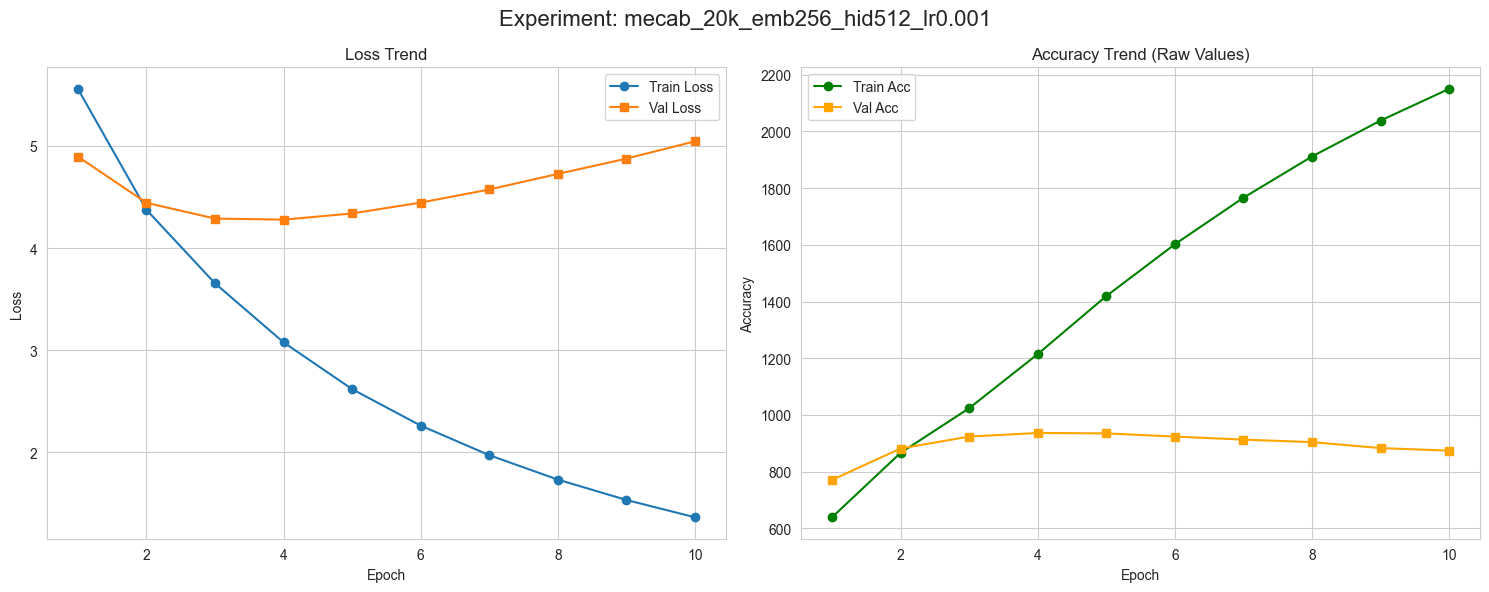

✅ 그래프가 저장되었습니다: experiments\mecab_20k_emb256_hid512_lr0.001\result_plot.png


In [143]:
plot_history("mecab_20k_emb256_hid512_lr0.001")

In [141]:
# 1. 20k에 맞는 차원 설정 
input_dim = 20000
output_dim = 20000

# 2. 모델 객체 다시 생성 및 GPU 이동
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(f"Model re-initialized for 10k on: {device}")
print(f"Input Dim: {input_dim}, Output Dim: {output_dim}")

# 3. 10k 가중치 파일 로드
model_path = 'experiments/mecab_20k_emb256_hid512_lr0.001/best_model.pt'
model.load_state_dict(torch.load(model_path))
model.eval()

print("✅ 20k 가중치 로드 성공!")

Model re-initialized for 10k on: cuda
Input Dim: 20000, Output Dim: 20000
✅ 20k 가중치 로드 성공!


(폰트 설정: NanumBarunGothic)

[K1] 테스트
Input: 오바마 는 대통령 이 다 .
Predicted: obama s inauguration is a .


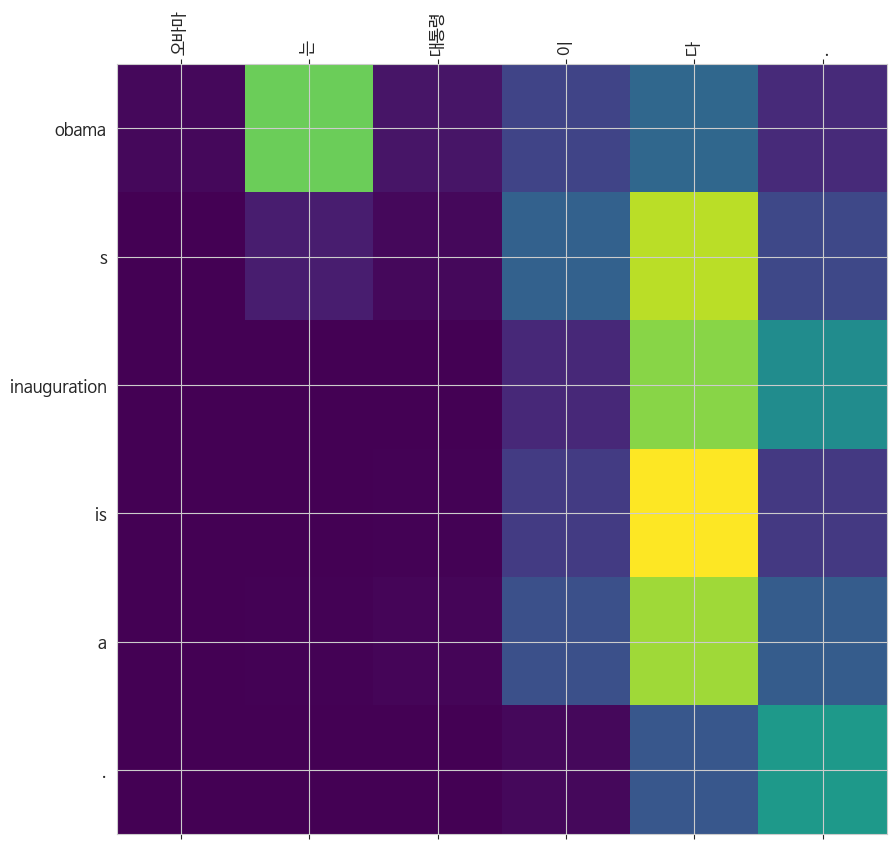


[K2] 테스트
Input: 시민 들 은 도시 속 에 <unk> .
Predicted: citizens in the city .


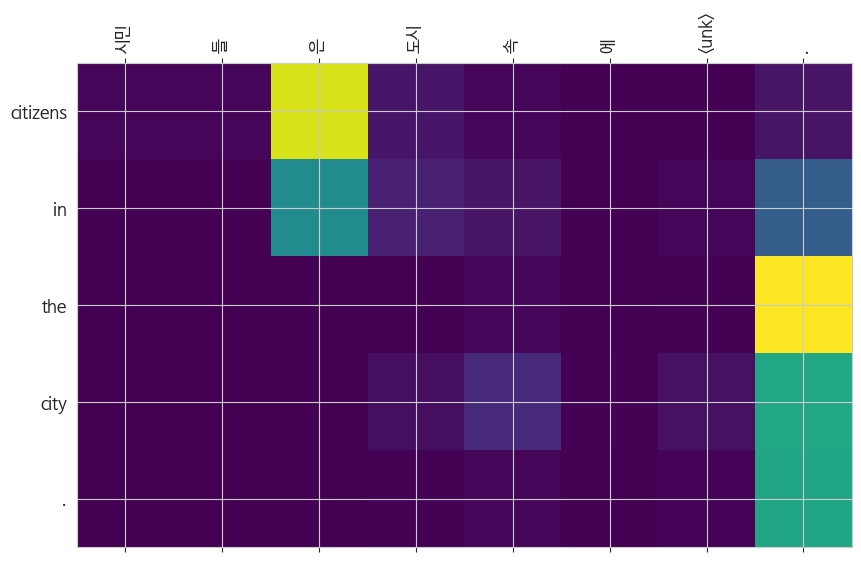


[K3] 테스트
Input: 커피 는 필요 없 다 .
Predicted: he is not going to be a bit of the uci .


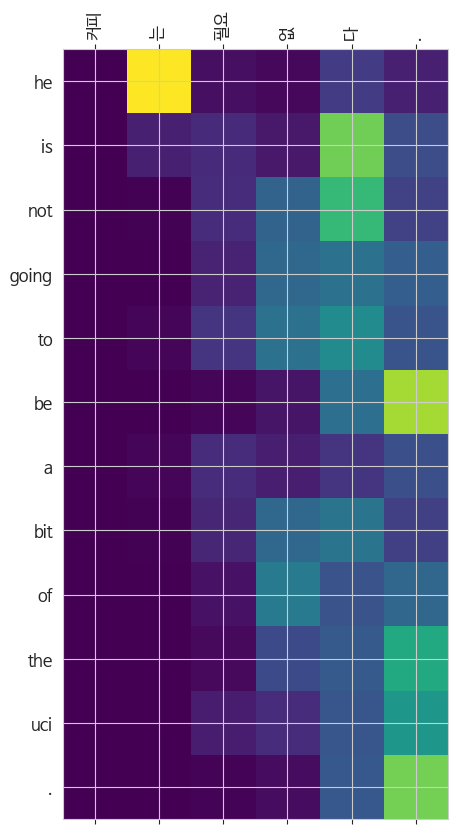


[K4] 테스트
Input: 일곱 명 의 사망자 가 발생 했 다 .
Predicted: the death toll from the death toll in the death toll from the death toll .


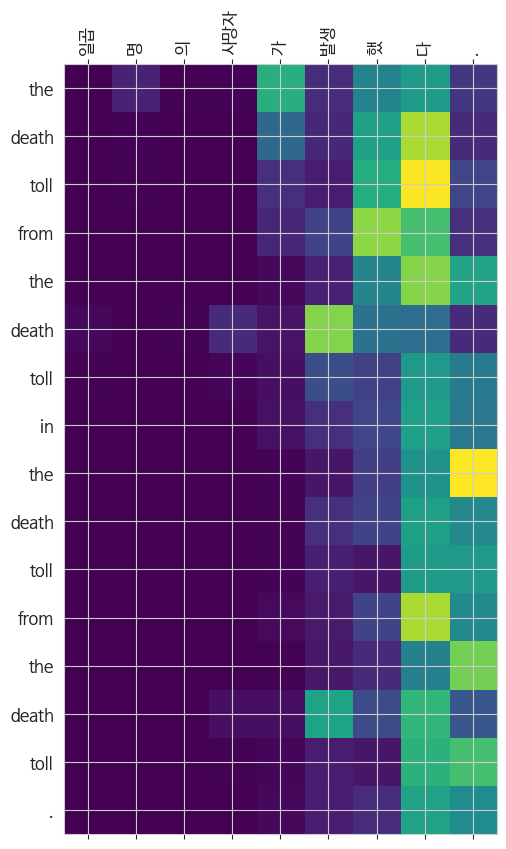

In [142]:
# 테스트 문장 리스트
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

print(f"(폰트 설정: {font_name})")

for i, sent in enumerate(test_sentences):
    print(f"\n[K{i+1}] 테스트")
    # evaluate 함수를 통해 결과 획득 (딕셔너리 버전 사용)
    result, src_tokens, att_map = evaluate_sentence(
        sentence=sent, 
        model=model, 
        kor_word2idx=kor_word2idx, 
        eng_idx2word=eng_idx2word, 
        max_len=MAX_LEN
    )
    
    print(f"Input: {' '.join(src_tokens)}")
    print(f"Predicted: {' '.join(result)}")
    
    # 시각화 (보강된 함수 호출)
    plot_attention(att_map, src_tokens, result)

## Vocab size 별 모델 성능 비교 (10k vs 20k)

### 1. 지표 요약 (10 Epoch 기준)

| 지표 (10 Epoch) | mecab_10k (Vocab 10,000) | mecab_20k (Vocab 20,000) | 비고 |
| :--- | :--- | :--- | :--- |
| **Best Val Loss** | **3.9625 (Epoch 02)** | 4.2787 (Epoch 04) | 10k가 더 낮은 손실값 도달 |
| **Final Train Loss** | 1.266 | 1.366 | 10k의 학습 속도가 소폭 빠름 |
| **Final Val Loss** | 4.894 | 5.045 | 두 모델 모두 후반부 과적합 경향 |
| **학습 속도 (it/s)** | **~3.7 it/s** | ~2.9 it/s | 20k 모델이 약 27% 더 느림 |

---

### 2. Loss 하락 추이 및 분석

#### 10k 모델: "빠른 수렴, 그러나 이른 과적합"
* **초기 수렴:** 1Epoch부터 Loss가 3.5대로 시작하여 매우 빠르게 떨어집니다.
* **과적합(Overfitting):** **Epoch 02**에서 이미 최저 Val Loss(3.96)를 찍고 이후부터는 계속 상승합니다. 이는 모델이 10k 단어장에 대해 너무 빨리 "암기"를 시작했음을 의미합니다.

#### 20k 모델: "더딘 출발, 하지만 높은 잠재력"
* **초기 수렴:** 단어장이 2배 크기 때문에 초기 Loss가 5.5대로 높게 시작하며, 최저 Val Loss 도달 시점도 **Epoch 04**로 10k보다 늦습니다.
* **학습 안정성:** 10k에 비해 Val Loss가 튀는 현상이 상대적으로 덜하며, 더 많은 정보를 담으려 노력하는 모습이 보입니다. 다만, 역시 5Epoch 이후로는 과적합 구간에 진입했습니다.

---




### 3. 번역 결과 비교표

| 번호 | 입력 문장 (Korean) | 10k 모델 결과 (Predicted) | 20k 모델 결과 (Predicted) | 분석 비고 |
| :--- | :--- | :--- | :--- | :--- |
| **K1** | 오바마 는 대통령 이 다 . | **obama is the president .** | obama s inauguration is a . | 10k 완승 |
| **K2** | 시민 들 은 도시 속 에 \<unk\> . | citizens , the city s \<unk\> \<unk\> . | **citizens in the city .** | 20k의 자연스러운 전치사 처리 |
| **K3** | 커피 는 필요 없 다 . | the \<unk\> of the coffee is no longer . | he is not going to be a bit of the uci . | 10k는 소재 유지, 20k는 맥락 이탈 |
| **K4** | 일곱 명 의 사망자 가 발생 했 다 . | the dead were killed . | the death toll from the death toll... | 20k 무한 루프(Repetition) 발생 |

---

### 4. 주요 모델별 분석 (Insight)

####  10k 모델: "기초가 탄탄한 안정형"
* **안정성:** 학습 데이터셋 내의 빈도가 높은 문장 구조(K1)에 대해 매우 높은 신뢰도를 보임.
* **한계:** 어휘량(Vocab)의 부족으로 인해 조금만 문장이 복잡해지면 `<unk>` 토큰이 발생하거나 문장이 불필요하게 길어지는 경향이 있음.

####  20k 모델: "잠재력은 높으나 아직 덜 익은 성장형"
* **표현력:** K2의 결과에서 보듯, 더 넓은 어휘 사전을 바탕으로 훨씬 세련된 영어 표현(`in the city`)을 구사할 가능성을 보여줌.
* **학습 부족 현상:** 
    * **Hallucination(환각):** `obama`를 보고 관련 단어인 `inauguration`(취임식)을 내뱉는 등 단어 간의 정확한 일대일 대응이 아직 부족함.
    * **Repetition(반복):** K4에서 보듯 동일한 문구를 반복하는 현상은 모델이 다음에 올 단어의 확률 분포를 아직 명확히 학습하지 못했을 때 나타나는 전형적인 초기 증상.


## 종합 결론: 10k vs 20k, 어떤 모델을 선택할 것인가?

본 실험에서는 어휘 사전(Vocab Size)의 크기가 번역 모델의 수치적 지표(Loss)와 실제 번역 품질(Translation Quality)에 미치는 영향을 분석하였다.

### 1. 지표 분석 (Quantitative Analysis)
* **10k 모델의 효율성:** 10k 모델은 학습 속도가 20k 대비 약 27% 빠르며, 최저 Validation Loss(3.96)에 도달하는 시점도 매우 빨랐다. 제한된 데이터셋 환경에서는 10k 모델이 수렴 성능 면에서 우위를 점한다.
* **과적합(Overfitting) 발생 시점:** 두 모델 모두 2~4 Epoch 사이에서 최저 Val Loss를 기록한 후 반등하였다. 이는 현재 데이터 규모에서 10 Epoch 학습은 과도하며, Early Stopping(Patience 2-3) 도입이 필수적임을 시사한다.

### 2. 출력 결과 분석 (Qualitative Analysis)
* **표현의 유연성 (20k 우세):** 20k 모델은 Loss 수치는 다소 높으나, `citizens in the city`와 같이 더 자연스러운 영어 전치사 및 관용 표현을 구사하는 잠재력을 보여주었다. 
* **정확도 및 안정성 (10k 우세):** 10k 모델은 어휘량이 적은 대신 고유 명사(Obama 등)와 기본 문장 구조를 더 정확하게 매칭하였다. 반면 20k 모델은 학습 부족으로 인해 비슷한 맥락의 단어를 섞어 쓰는 '환각(Hallucination)' 및 '반복(Repetition)' 현상이 관찰되었다.

### 3. 최종 제안 (Final Recommendation)
* **현 단계 최적 모델:** 안정적인 번역을 원한다면 **10k 모델의 2 Epoch 시점 체크포인트**를 사용하는 것이 가장 유리하다.
* **확장 가능성:** 더 매끄럽고 풍부한 번역을 원한다면 **20k 모델에 대한 추가 데이터 확보 및 규제(Dropout, Weight Decay) 강화**가 필요하다. 20k 모델은 '그릇'은 크지만 아직 그 그릇을 다 채우지 못한 상태로 판단된다.

---
**💡 요약 한 줄:** "지표(Loss)는 10k가 앞서지만, 언어적 디테일은 20k가 유망하므로 목적에 따른 선택이 필요함."

## 회고

- Keep
    - Vocab Size별(10k, 20k) 대조군 실험을 설계하였다.
    - 모델 파라미터와 학습 추이를 기록하였다.

- Problem
    - Baseline 구현이 시행착오가 많아 오래 걸렸다. 
    - 학습 속도를 높이려고 Batch size 를 키웠더니 과적합이 빨리 온것 같다.
    - accuracy 계산이 이상하다.

- Try
    - Teacher Forcing 비율을 조정해서 테스트 해본다.
    - batch size 를 64로 낮춰 테스트 해본다.
    - 과적합 방지를 위해 dropout 이나 weight decay 를 사용한다.
